# Market Basket Analysis — Product Affinity & Cross-Sell Rules

Uses the Apriori algorithm to find products frequently bought together,
and generates cross-sell recommendations.

**Input:** 'C:\Users\shahul\Downloads\royal_store_cleaned'

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import apriori, association_rules
from itertools import chain

df = pd.read_csv(r"C:\Users\shahul\Downloads\royal_store_cleaned")
df['Date'] = pd.to_datetime(df['Date'])
df['IsReturn'] = df['IsReturn'].astype(str).str.strip().str.lower() == 'true'
df_sales = df[df['IsReturn'] == False].copy()

print(f"Total bills     : {df['Bill.NO'].nunique()}")
print(f"After returns   : {df_sales['Bill.NO'].nunique()}")
print(f"Unique products : {df_sales['Product Name'].nunique()}")
print(f"Date range      : {df_sales['Date'].min().date()} → {df_sales['Date'].max().date()}")

Total bills     : 39204
After returns   : 39204
Unique products : 4610
Date range      : 2025-04-01 → 2025-07-08


## 1. Build the Basket Matrix
Keep only multi-item bills, and only products appearing in ≥0.5% of bills
to keep the itemset search tractable.

In [4]:
# Keep only multi-item bills
items_per_bill = df_sales.groupby('Bill.NO')['Product Name'].nunique()
multi_bill_ids = items_per_bill[items_per_bill >= 2].index
df_multi = df_sales[df_sales['Bill.NO'].isin(multi_bill_ids)]

# Build matrix
basket = df_multi.groupby(['Bill.NO', 'Product Name'])['Qty'].sum().unstack().fillna(0)
basket = basket.map(lambda x: 1 if x > 0 else 0).astype(bool)

# Filter to products in at least 0.5% of bills
min_freq = int(len(basket) * 0.005)
popular = basket.sum()[basket.sum() >= min_freq].index
basket = basket[popular]

print(f"Bills           : {basket.shape[0]}")
print(f"Products        : {basket.shape[1]}")
print(f"Min frequency   : {min_freq} bills")

Bills           : 22560
Products        : 220
Min frequency   : 112 bills


## 2. Run Apriori & Generate Association Rules

In [5]:
frequent_itemsets = apriori(basket, min_support=0.003, use_colnames=True, max_len=3)
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(len)

print(f"Frequent itemsets : {len(frequent_itemsets)}")
print(frequent_itemsets['length'].value_counts().sort_index())

Frequent itemsets : 257
length
1    220
2     37
Name: count, dtype: int64


In [6]:
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)
rules['confidence_%'] = (rules['confidence'] * 100).round(1)

strong_rules = rules[
    (rules['confidence'] >= 0.2) & (rules['lift'] >= 1.2)
].sort_values('lift', ascending=False).reset_index(drop=True)

print(f"Total rules  : {len(rules)}")
print(f"Strong rules : {len(strong_rules)}")
strong_rules[['antecedents', 'consequents', 'support', 'confidence_%', 'lift']].head(10)

Total rules  : 74
Strong rules : 36


,antecedents,consequents,support,confidence_%,lift
0,(ANNACHIPOO10GM),(KAL PASI 10GM),0.003147,45.5,80.847971
1,(KAL PASI 10GM),(ANNACHIPOO10GM),0.003147,55.9,80.847971
2,(JEERAGAM 100GM),(SOMBU 100GM),0.005186,37.5,47.796610
3,(SOMBU 100GM),(JEERAGAM 100GM),0.005186,66.1,47.796610
4,(THIRACHAI 50GM),(MUNTHIRI 25GM),0.006516,47.4,38.070486
5,(MUNTHIRI 25GM),(THIRACHAI 50GM),0.006516,52.3,38.070486
6,(SOMBU 50G),(JEERAGAM 50GM),0.003989,47.4,32.382775
7,(JEERAGAM 50GM),(SOMBU 50G),0.003989,27.3,32.382775
8,(AASHIRVAAD CRYSTAL SALT 1KG),(AASHIRVAAD SALT 1KG),0.004122,28.6,29.210999
9,(AASHIRVAAD SALT 1KG),(AASHIRVAAD CRYSTAL SALT 1KG),0.004122,42.1,29.210999


## 3. Visualize Top Rules

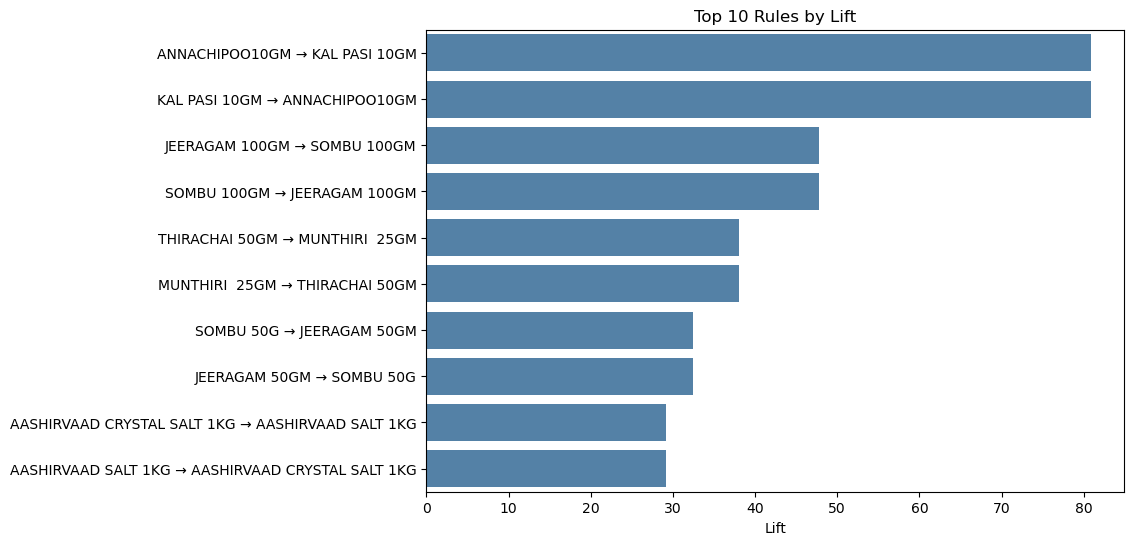

In [7]:
top10 = strong_rules.head(10).copy()
top10['rule'] = (top10['antecedents'].apply(lambda x: ', '.join(list(x))) + ' → ' +
                  top10['consequents'].apply(lambda x: ', '.join(list(x))))

plt.figure(figsize=(9, 6))
sns.barplot(data=top10, y='rule', x='lift', color='steelblue')
plt.title('Top 10 Rules by Lift')
plt.xlabel('Lift')
plt.ylabel('')
plt.show()

## 4. Product Affinity Heatmap

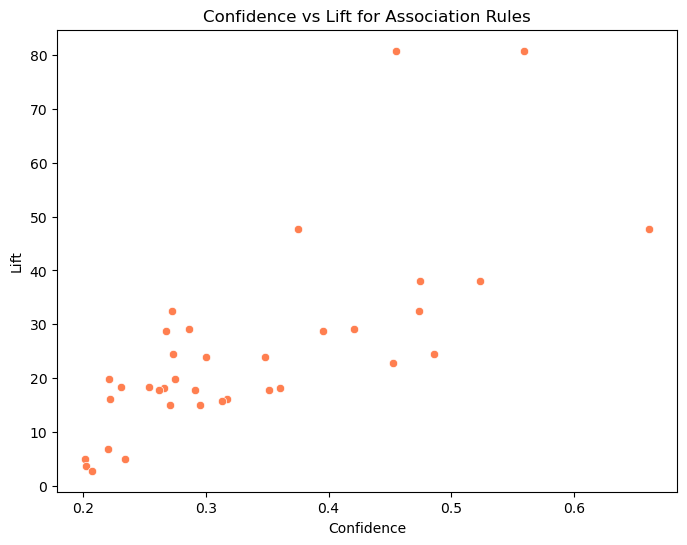

In [8]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=strong_rules, x='confidence', y='lift', color='coral')
plt.title('Confidence vs Lift for Association Rules')
plt.xlabel('Confidence')
plt.ylabel('Lift')
plt.show()

## 5. Cross-Sell Recommendations

In [9]:
print("=" * 65)
print("  CROSS-SELL RECOMMENDATIONS")
print("=" * 65)
for _, row in strong_rules.head(15).iterrows():
    ant = ', '.join(list(row['antecedents']))
    con = ', '.join(list(row['consequents']))
    print(f"\n  Customer buys : {ant}")
    print(f"  Recommend     : {con}")
    print(f"  Confidence    : {row['confidence_%']}%  |  Lift: {round(row['lift'], 1)}x")
    print(f"  {'-' * 55}")

  CROSS-SELL RECOMMENDATIONS

  Customer buys : ANNACHIPOO10GM
  Recommend     : KAL PASI 10GM
  Confidence    : 45.5%  |  Lift: 80.8x
  -------------------------------------------------------

  Customer buys : KAL PASI 10GM
  Recommend     : ANNACHIPOO10GM
  Confidence    : 55.9%  |  Lift: 80.8x
  -------------------------------------------------------

  Customer buys : JEERAGAM 100GM
  Recommend     : SOMBU 100GM
  Confidence    : 37.5%  |  Lift: 47.8x
  -------------------------------------------------------

  Customer buys : SOMBU 100GM
  Recommend     : JEERAGAM 100GM
  Confidence    : 66.1%  |  Lift: 47.8x
  -------------------------------------------------------

  Customer buys : THIRACHAI 50GM
  Recommend     : MUNTHIRI  25GM
  Confidence    : 47.4%  |  Lift: 38.1x
  -------------------------------------------------------

  Customer buys : MUNTHIRI  25GM
  Recommend     : THIRACHAI 50GM
  Confidence    : 52.3%  |  Lift: 38.1x
  ---------------------------------------------